# PiSSA 交互教学

配套 lecture：[`../lectures/03-pissa.md`](../lectures/03-pissa.md)  
配套论文：[`../papers/03-pissa-2024.pdf`](../papers/03-pissa-2024.pdf) · [`../papers/附-olora-2024.pdf`](../papers/附-olora-2024.pdf)

本 notebook 演示：
1. 环境检查
2. SVD 主成分初始化（PiSSA）
3. QR 正交初始化（OLoRA 附录）
4. **强一致性验证**：W_res + BA = W_0
5. peft 调包对照
6. **mini training**：PiSSA vs LoRA vs OLoRA 三方对比
7. 思考题

In [1]:
import sys
from pathlib import Path
import torch
print(f'torch: {torch.__version__}')

torch: 2.13.0.dev20260602+cu130


## 2. PiSSA: 用 W_0 的 SVD 主成分初始化

公式 (1)(2)(3): W_0 = U Σ V^T → B = U_:r √Σ_:r, A = √Σ_:r V^T_:r → W_res = W_0 - BA

In [2]:
src_dir = (Path.cwd().parent / 'src').resolve()
sys.path.insert(0, str(src_dir))

from pissa_minimal import PiSSAGPT2, PiSSALinear
from common import print_param_summary

torch.manual_seed(42)
pissa = PiSSAGPT2(r=8, alpha=8, init_method='pissa')
print_param_summary(pissa, 'PiSSA (r=8, init=pissa)')

# 看第一层 layer 0 的 B、A
layer0 = pissa.lm.transformer.h[0].attn.c_attn
print(f'\n第一层 layer 0:')
print(f'  B shape: {tuple(layer0.B.shape)}  (来自 U_:r √Σ_:r)')
print(f'  A shape: {tuple(layer0.A.shape)}  (来自 √Σ_:r V^T_:r)')
print(f'  B 范数: {layer0.B.norm():.4f}')
print(f'  A 范数: {layer0.A.norm():.4f}')
print(f'  对比 LoRA 的零初始化: 这里 B、A 都非零！')

C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 19676.59it/s]

  PiSSA (r=8, init=pissa)
  Total params:      124,734,720
  Trainable params:      294,912  (0.2364%)
  Frozen params:     124,439,808

第一层 layer 0:
  B shape: (2304, 8)  (来自 U_:r √Σ_:r)
  A shape: (8, 768)  (来自 √Σ_:r V^T_:r)
  B 范数: 15.6856
  A 范数: 15.6856
  对比 LoRA 的零初始化: 这里 B、A 都非零！


## 3. OLoRA：QR 正交初始化（附录）

In [3]:
torch.manual_seed(42)
olora = PiSSAGPT2(r=8, alpha=8, init_method='olora')
print_param_summary(olora, 'OLoRA (r=8, init=olora)')

olora_layer0 = olora.lm.transformer.h[0].attn.c_attn
# 检查 B 是否列正交（OLoRA 的关键性质）
B_TB = olora_layer0.B.T @ olora_layer0.B
I_r = torch.eye(8)
print(f'\nOLoRA B^T B - I 的 Frobenius 范数: {(B_TB - I_r).norm():.4e}')
print('→ 接近 0，证明 B 列正交（QR 的性质）')

# 对比 PiSSA 的 B：U_:r √Σ_:r 不是正交（因为乘了 √Σ）
pissa_layer0 = pissa.lm.transformer.h[0].attn.c_attn
pissa_B_TB = pissa_layer0.B.T @ pissa_layer0.B
print(f'PiSSA B^T B - I 的 Frobenius 范数: {(pissa_B_TB - I_r).norm():.4e}')
print('→ 较大，PiSSA B 不正交（含 √Σ scaling）')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 15357.67it/s]

  OLoRA (r=8, init=olora)
  Total params:      124,734,720
  Trainable params:      294,912  (0.2364%)
  Frozen params:     124,439,808

OLoRA B^T B - I 的 Frobenius 范数: 4.5831e-07
→ 接近 0，证明 B 列正交（QR 的性质）
PiSSA B^T B - I 的 Frobenius 范数: 8.7664e+01
→ 较大，PiSSA B 不正交（含 √Σ scaling）


## 4. 强一致性验证：W_res + BA = W_0

In [4]:
tests_dir = (Path.cwd().parent / 'src' / 'tests').resolve()
sys.path.insert(0, str(tests_dir))
from test_pissa_consistency import test_pissa_init_reconstruction, test_pissa_initial_forward_match
test_pissa_init_reconstruction()
test_pissa_initial_forward_match()


[Test 1] PiSSA 初始重建: W_res + BA == W_0


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 14747.62it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 17368.69it/s]

...

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 15527.85it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 16139.49it/s]

  最大绝对误差: 7.6294e-05
  最大相对误差: 6.2318e-07
  [PASS]


## 5. peft 调包对照

In [5]:
from pissa_peft import build_peft_model

torch.manual_seed(42)
peft_pissa = build_peft_model(r=8, alpha=8, init_method='pissa')
print_param_summary(peft_pissa, 'peft PiSSA (init_lora_weights=pissa)')
print()
torch.manual_seed(42)
peft_olora = build_peft_model(r=8, alpha=8, init_method='olora')
print_param_summary(peft_olora, 'peft OLoRA (init_lora_weights=olora)')
print('\n→ 与 minimal 完全相同参数量')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 17585.18it/s]

W0603 15:49:15.129000 45344 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\peft\tuners\lora\layer.py:2504: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


  peft PiSSA (init_lora_weights=pissa)
  Total params:      124,734,720
  Trainable params:      294,912  (0.2364%)
  Frozen params:     124,439,808



Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 16318.96it/s]

  peft OLoRA (init_lora_weights=olora)
  Total params:      124,734,720
  Trainable params:      294,912  (0.2364%)
  Frozen params:     124,439,808

→ 与 minimal 完全相同参数量


## 6. Mini training: PiSSA vs LoRA vs OLoRA

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 18738.70it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 14239.51it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 17154.62it/s]

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


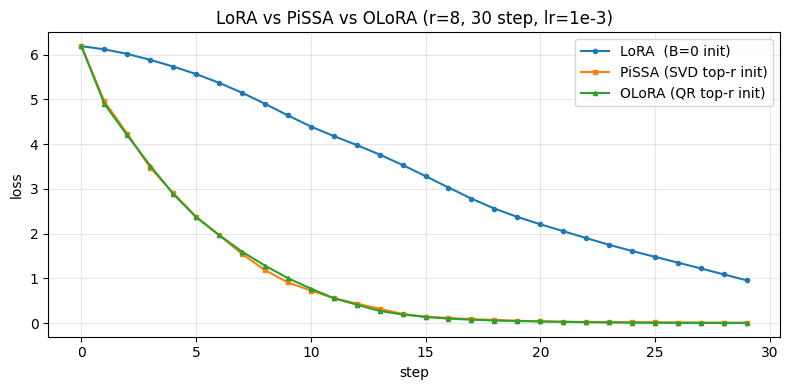

LoRA  final loss: 0.9584
PiSSA final loss: 0.0084
OLoRA final loss: 0.0078


In [6]:
import matplotlib.pyplot as plt
from lora_minimal import LoRAGPT2

torch.manual_seed(42)
lora = LoRAGPT2(r=8, alpha=8)
torch.manual_seed(42)
pissa = PiSSAGPT2(r=8, alpha=8, init_method='pissa')
torch.manual_seed(42)
olora = PiSSAGPT2(r=8, alpha=8, init_method='olora')

tok = lora.tokenizer
inputs = tok([
    'hello world this is a test',
    'i love this amazing wonderful product',
    'absolutely terrible movie do not buy',
    'fantastic experience from start to finish',
], return_tensors='pt', padding=True)
inputs['labels'] = inputs['input_ids'].clone()

models = [
    ('LoRA',  lora,  torch.optim.AdamW([p for p in lora.parameters() if p.requires_grad], lr=1e-3)),
    ('PiSSA', pissa, torch.optim.AdamW([p for p in pissa.parameters() if p.requires_grad], lr=1e-3)),
    ('OLoRA', olora, torch.optim.AdamW([p for p in olora.parameters() if p.requires_grad], lr=1e-3)),
]

losses = {name: [] for name, _, _ in models}
for step in range(30):
    for name, m, opt in models:
        opt.zero_grad()
        out = m(**inputs)
        out.loss.backward()
        opt.step()
        losses[name].append(out.loss.item())

plt.figure(figsize=(8, 4))
plt.plot(losses['LoRA'],  label='LoRA  (B=0 init)', marker='o', markersize=3)
plt.plot(losses['PiSSA'], label='PiSSA (SVD top-r init)', marker='s', markersize=3)
plt.plot(losses['OLoRA'], label='OLoRA (QR top-r init)', marker='^', markersize=3)
plt.xlabel('step')
plt.ylabel('loss')
plt.title('LoRA vs PiSSA vs OLoRA (r=8, 30 step, lr=1e-3)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"LoRA  final loss: {losses['LoRA'][-1]:.4f}")
print(f"PiSSA final loss: {losses['PiSSA'][-1]:.4f}")
print(f"OLoRA final loss: {losses['OLoRA'][-1]:.4f}")

## 7. 思考题

**主篇**：
1. **公式题**：证明 B = U_:r √Σ_:r, A = √Σ_:r V^T_:r 满足 BA = W_0^top_r。
2. **公式题**：如果改用 B = U_:r, A = Σ_:r V^T_:r（不分 sqrt），训练动力学有什么差异？
3. **代码题**：在 `pissa_minimal.py` 上加 5 行，保留前 2r 主成分作 warm restart 参数池。
4. **设计题**：PiSSA 在 domain 差异大的任务上可能不如 LoRA。给一个直觉解释。
5. **对比题**：列出 PiSSA、AdaLoRA、VeRA 三者使用 SVD 的方式差异。

**附录 OLoRA**：
6. 推导 QR 中 Q_:r 与 SVD 中 U_:r 生成的子空间的关系。
7. 跑 mini training 调换 r=4 与 r=64，看 PiSSA 与 OLoRA 的优势是否一致。